In [1]:
# mv this notebook in src folder
# or
# set sys path to src folder
import os, sys
path_to_scr_folder=os.path.join(os.path.dirname(os.path.abspath('')), 'src')
sys.path.append(path_to_scr_folder)


In [2]:
import plot
from read_chroma import read_only_chroma, read_chromato_and_chromato_cube
import matplotlib.pyplot as plt
from identification import compute_matches_identification, cohort_identification_alignment_input_format_txt, cohort_identification_to_csv, sample_identification
from matching import matching_nist_lib_from_chromato_cube
import projection
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

import mass_spec
from sklearn.cluster import DBSCAN
from scipy.signal import savgol_filter
from skimage.restoration import estimate_sigma
from dbscan_peak import detection_mass_par_mass_Dog
import dbscan_peak

In [216]:
file= os.listdir("D:/DC volatil cf 8")
file

['15-04-25_817822_QC_23newEI.cdf',
 '2025-04-16_751318_QCnew23EI.cdf',
 '2025-04-16_751321_QCnew23EI.cdf',
 '864683-QC-23EIs.cdf']

# Lecture du fichier

In [3]:
filename="/app/GCxGC/GCxGC/APPROCHS/001_2382_FA_J14.cdf"
filename="D:/VOLATIL-CF_03/751316_QCd20new.cdf"
filename="D:/GCxGC/APPROCHS/001_2382_FA_J14.cdf"
filename='D:/cdf centroid/B-A-009-751353-gauche-ReCIVA.cdf'
#filename='D:/cdf centroid/B-K-031-751355-Tedlar.cdf'
filename="D:/DC volatil cf 8/2025-04-16_751318_QCnew23EI.cdf"
filename = "D:/GCxGC/gamme/751343_gamme_1ppm.cdf"
filename='D:/cdf centroid/A-F-028-817822-droite-ReCIVA.cdf'

chromato, time_rn, chromato_cube, sigma, mass_range=read_chromato_and_chromato_cube(filename, mod_time=1.7, pre_process=True)

KeyboardInterrupt: 

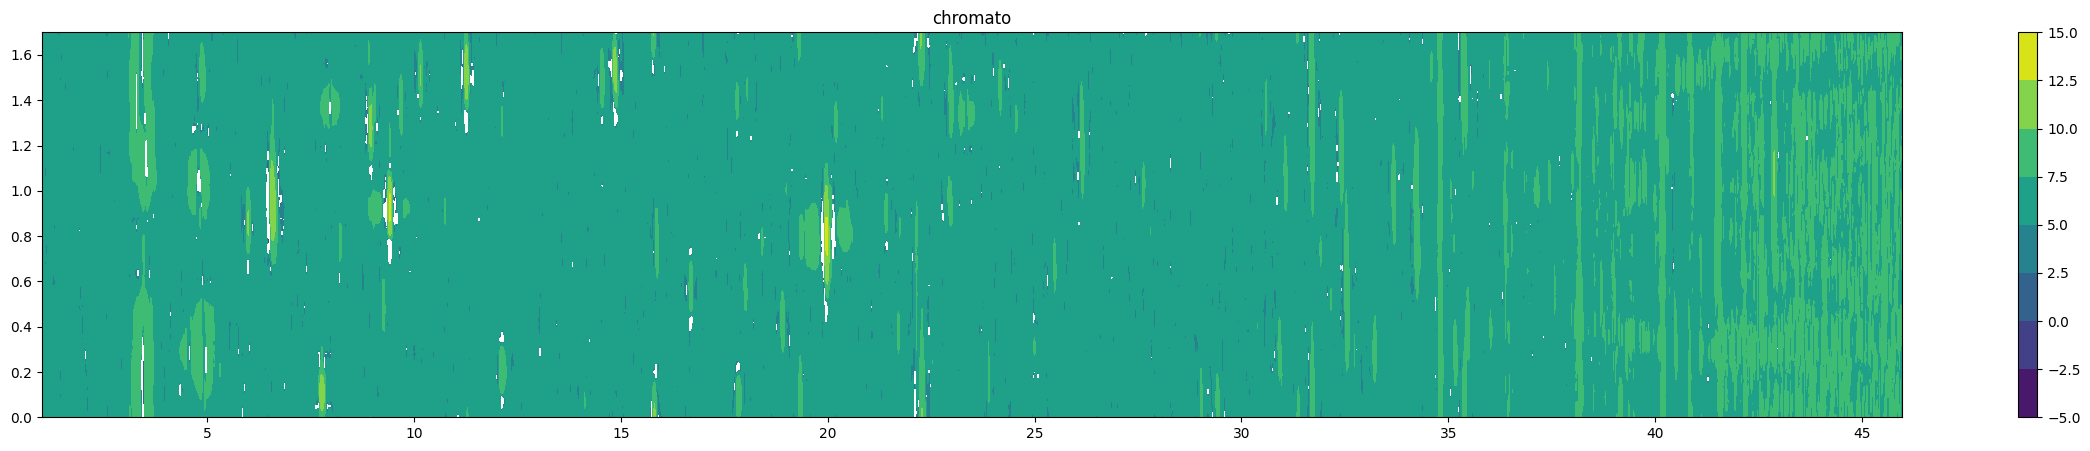

In [ ]:
plt.rcParams['figure.figsize'] = [30, 5]
plot.visualizer2((chromato_cube[90-35,:,:], time_rn), title="chromato", log_chromato=True,  mod_time=1.7)

In [13]:
coordinates = dbscan_peak.detection_mass_par_mass_Dog(chromato_cube,(chromato, time_rn),
                                                            1.7,
                                                                abs_threshold=500,
                                                                rel_threshold=0.0001,
                                                                noise_factor=3,
                                                                min_sigma=1,
                                                                max_sigma=20,
                                                                sigma_ratio=2,
                                                                overlap=0.5, 
                                                                max_peak_per_mass=600,
                                                                rt1_delta=1, 
                                                                rt2_delta=0.01,
                                                                min_size_cluster_mass=3, 
                                                                thr_debscan=0.01, 
                                                                multi_processing=True,
                                                                cleaning_close_peak=True)




start peak detection
cluster_per_mass 
compute distance metric 23223 peaks
start clustering
2529 peaks clustered
2008 detected peaks after filter


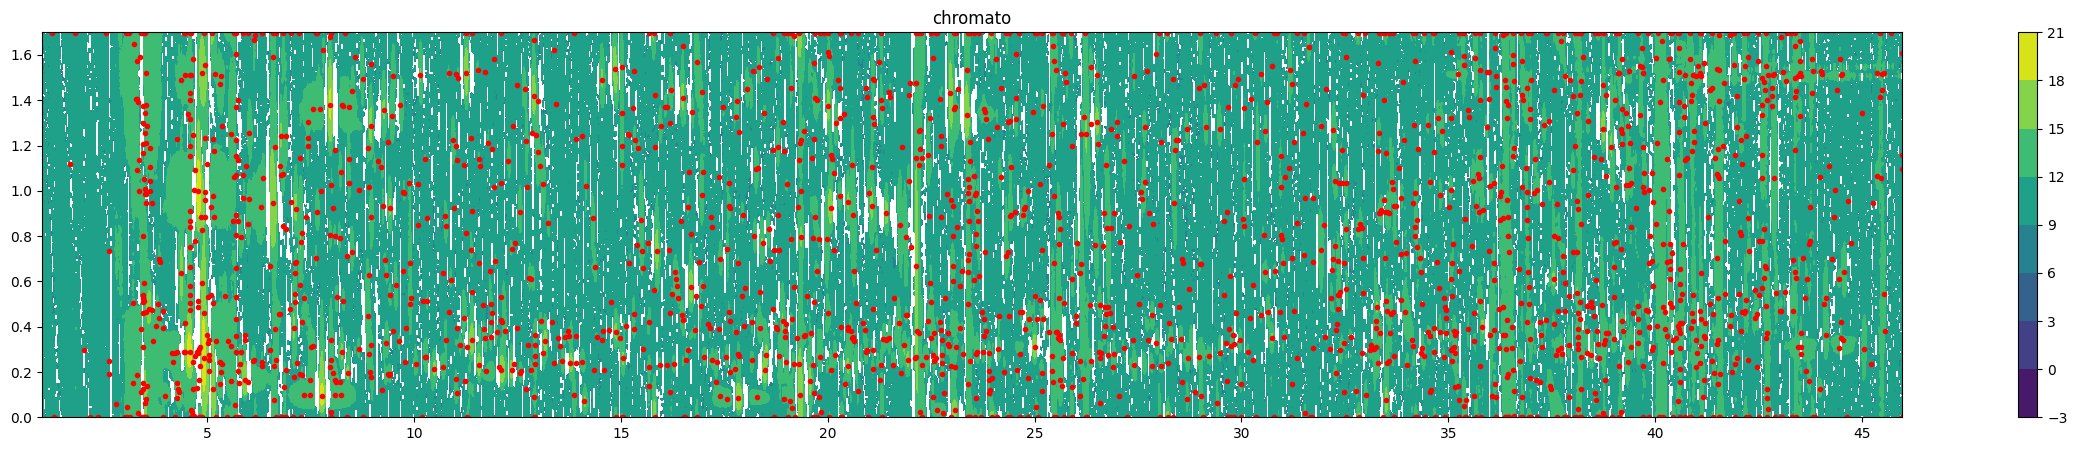

In [ ]:
plt.rcParams['figure.figsize'] = [30, 5]
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
plot.visualizer2((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)

In [15]:
import matching
matches = matching.matching_nist_lib_from_chromato_cube(
            (chromato, time_rn, mass_range), chromato_cube, coordinates,
            mod_time=1.7,
            match_factor_min=700, nist=False)
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)

NIST skipped


In [ ]:
import pandas as pd
import logging
import pyms
import pyms_nist_search

def matching_from_spectra(spectra):
    search = pyms_nist_search.Engine(
        "C:/Users/camil/Documents/NIST/mainlib/",
        pyms_nist_search.NISTMS_MAIN_LIB,
        "C:/Users/camil/Documents/NIST/mainlib/",
        )

    logger=logging.getLogger('pyms_nist_search')
    logger.setLevel('ERROR')
    logger=logging.getLogger('pyms')
    logger.setLevel('ERROR')
    masses=  np.arange(35, len(spectra)+35)

    mass_spectrum = pyms.Spectrum.MassSpectrum(masses, spectra)
    hits = search.full_search_with_ref_data(mass_spectrum, n_hits=5)
    return hits

import warnings
warnings.filterwarnings("ignore")
test=[]
for item in (matches):
    test.append(matching_from_spectra(item[1][0]['spectra'] )[0][0].match_factor)


In [ ]:
import warnings
warnings.filterwarnings("ignore")
test=[]
for item in (matches):
    test.append(matching_from_spectra(item[1][0]['spectra'] )[0][0].match_factor)

(array([ 1.,  0.,  0.,  1.,  0.,  4.,  3.,  6.,  6.,  8.,  6.,  5., 14.,
         6., 12., 11.,  9.,  8., 11.,  5., 11., 11.,  7.,  9., 12.,  7.,
        12.,  7.,  6.,  4.,  3.,  6.,  3.,  7.,  4.,  7.,  4.,  7.,  8.,
         9.,  6., 16.,  9.,  5.,  6.,  7.,  8.,  2.,  1.,  3.]),
 array([482.  , 491.54, 501.08, 510.62, 520.16, 529.7 , 539.24, 548.78,
        558.32, 567.86, 577.4 , 586.94, 596.48, 606.02, 615.56, 625.1 ,
        634.64, 644.18, 653.72, 663.26, 672.8 , 682.34, 691.88, 701.42,
        710.96, 720.5 , 730.04, 739.58, 749.12, 758.66, 768.2 , 777.74,
        787.28, 796.82, 806.36, 815.9 , 825.44, 834.98, 844.52, 854.06,
        863.6 , 873.14, 882.68, 892.22, 901.76, 911.3 , 920.84, 930.38,
        939.92, 949.46, 959.  ]),
 <BarContainer object of 50 artists>)

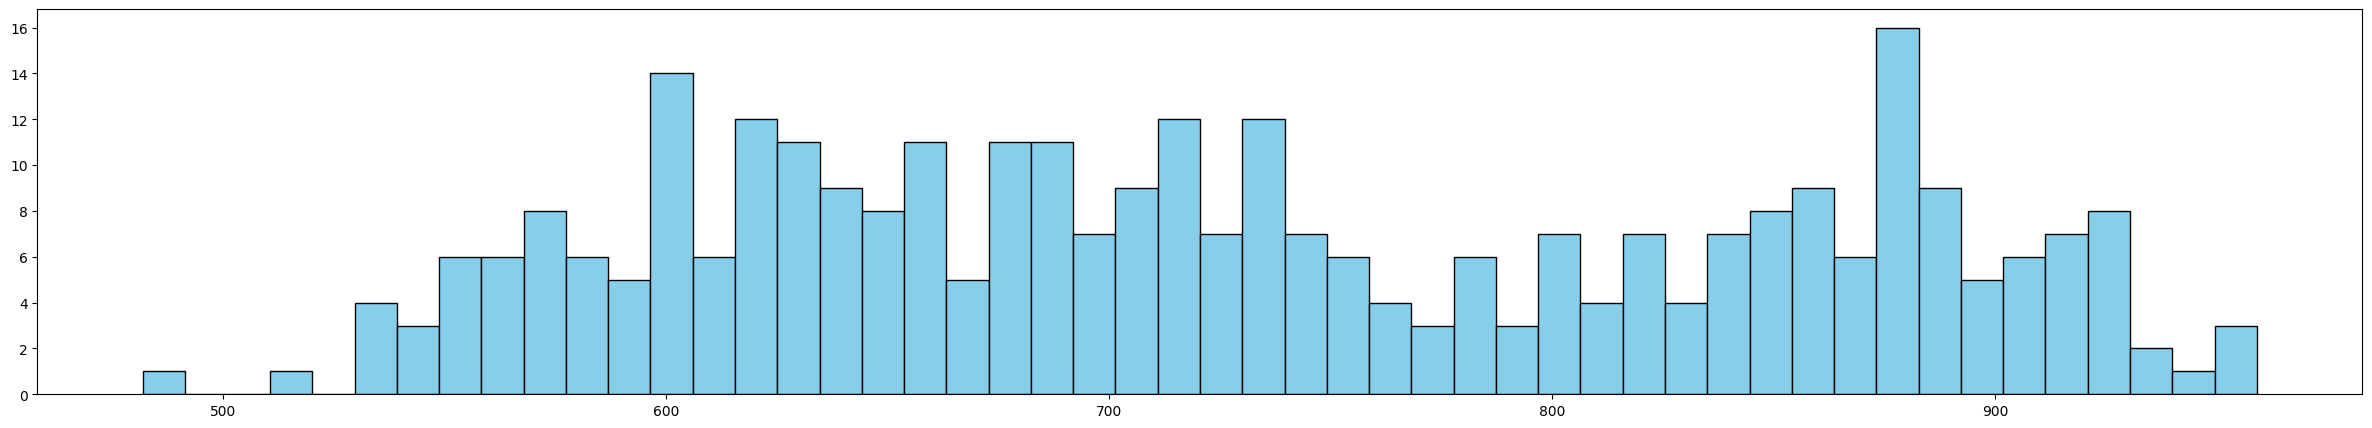

In [2069]:
plt.hist(test, bins=50, color='skyblue', edgecolor='black')


In [ ]:
base_name = os.path.basename(filename)
matches_identification, sample_metadata_list = compute_matches_identification(
            matches, chromato, chromato_cube,time_rn,1.7, mass_range,base_name,
            formated_spectra=True, quant="mass",extract_patch=True,output_hdf5_file="D:/data_set_tedlar.h5")

NIST skipped


In [ ]:
sample_identification("D:/cdf centroid", "B-K-031-751355-Tedlar.cdf", "D:/",
                          mod_time=1.7,
                          method="DoG", mode="mass_per_mass",
                          noise_factor=5, abs_thresholds=1000,
                          rel_thresholds=0.001,
                          cluster=0.5,
                          min_distance=1, min_sigma=1, max_sigma=20, sigma_ratio=2,
                          num_sigma=10,
                          formated_spectra=True, match_factor_min=600, min_persistence=0.0002,
                          overlap=0.5, eps=0.001, min_samples=1, nist=False,quant_method="mass", extract_patch=True,output_hdf5_file= "D:/data_set_tedlar.h5")

In [17]:
import h5py
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd

file_path = 'D:/data_set_tedlar.h5'
group_name = 'A-F-028-817822-droite-ReCIVA'
csv_file = 'D:/A-F-028-817822-droite-ReCIVA_sample_metadata.csv'
df = pd.read_csv(csv_file, sep=';')

with h5py.File(file_path, 'r') as h5_file:
    group = h5_file[group_name]
    keys = list(group.keys())
    clip_patch_indices = [i for i, key in enumerate(keys) if "clip_patch" in key]

    pdf = PdfPages('D:/clip_patches_A-F-028-817822-droite-ReCIVA.pdf')  # Open PDF explicitly

    for ixd in clip_patch_indices:
        selected_key = keys[ixd]
        matched_row = df[df['clip_patch_id'] == selected_key]
        data = group[selected_key][:]

        fig, ax = plt.subplots(figsize=(6, 6))
        contour_plot = ax.contourf(data.T, cmap='viridis')
        ax.set_title(f"{matched_row.iloc[0]['mass']} / { round(matched_row.iloc[0]['RT1_theoretical'],4)}/ {round(matched_row.iloc[0]['RT2_theoretical'],4)}", fontsize=10)
        ax.axis('off')

        pdf.savefig(fig)  # Save current figure to PDF
        plt.close(fig)    # Close figure to free memory

    pdf.close()  # Close the PDF file explicitly


In [7]:
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)


In [ ]:
import h5py
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd

file_path = 'D:/data_set_tedlar.h5'
group_name = 'A-F-028-817822-droite-ReCIVA'
csv_file = 'D:/A-F-028-817822-droite-ReCIVA_sample_metadata.csv'
df = pd.read_csv(csv_file, sep=';')

with h5py.File(file_path, 'r') as h5_file:
    group = h5_file[group_name]
    keys = list(group.keys())
    clip_patch_indices = [i for i, key in enumerate(keys) if "clip_patch" in key]

    pdf = PdfPages('D:/clip_patches_plots_A-F-028-817822-droite-ReCIVA.pdf')  # Open PDF explicitly

    for ixd in clip_patch_indices[:1500]:
        selected_key = keys[ixd]
        matched_row = df[df['clip_patch_id'] == selected_key]
        data = group[selected_key][:]
        
        plt.rcParams['figure.figsize'] = [10, 5]
        fig=plot.visualizer2((chromato_cube[matched_row.iloc[0]['mass']-mass_range[0],:,:], time_rn), 
                         title=f"{matched_row.iloc[0]['mass']} / { round(matched_row.iloc[0]['RT1_theoretical'],4)}/ {round(matched_row.iloc[0]['RT2_theoretical'],4)}", 
                         log_chromato=False,  mod_time=1.7, 
                 rt1=matched_row.iloc[0]['RT1_theoretical'], rt2=matched_row.iloc[0]['RT2_theoretical'], 
                 rt1_window=0.1,rt2_window=0.2,points=coordinates_in_chromato)

        pdf.savefig(fig)  # Save current figure to PDF
        plt.close(fig)    # Close figure to free memory

    pdf.close()  # Close the PDF file explicitly

In [7]:
import pandas as pd
import glob
import os

# Folder where your files are located
folder_path = "D:/"

# Find all CSV files ending with 'metadata.csv'
csv_files = glob.glob(os.path.join(folder_path, "*metadata.csv"))

# List to collect all DataFrames
df_list = []

for file in csv_files:
    print(f"Reading: {file}")
    df = pd.read_csv(file, sep=';')  # Adjust sep if needed
    df_list.append(df)

# Concatenate all DataFrames
df_combined = pd.concat(df_list, ignore_index=True)

# Save to a new CSV if needed
df_combined.to_csv(os.path.join(folder_path, "combined_metadata.csv"), sep=';', index=False)

Reading: D:/H-N-027-802116-Tedlarsample_metadata.csv
Reading: D:/M-J-022-864685-Tedlarsample_metadata.csv
Reading: D:/T-T-030-801850-Tedlarsample_metadata.csv


# Wrapper

start peak detection
cluster_per_mass 
compute distance metric 16429 peaks
start clustering
1708 peaks clustered
1635 detected peaks after filter


c:\Users\camil\OneDrive\Documents\02-Code source\Adeline\Python-2DGC-Alignment\src\plot.py:632: RuntimeWarning: divide by zero encountered in log
  chromato = np.log(chromato)


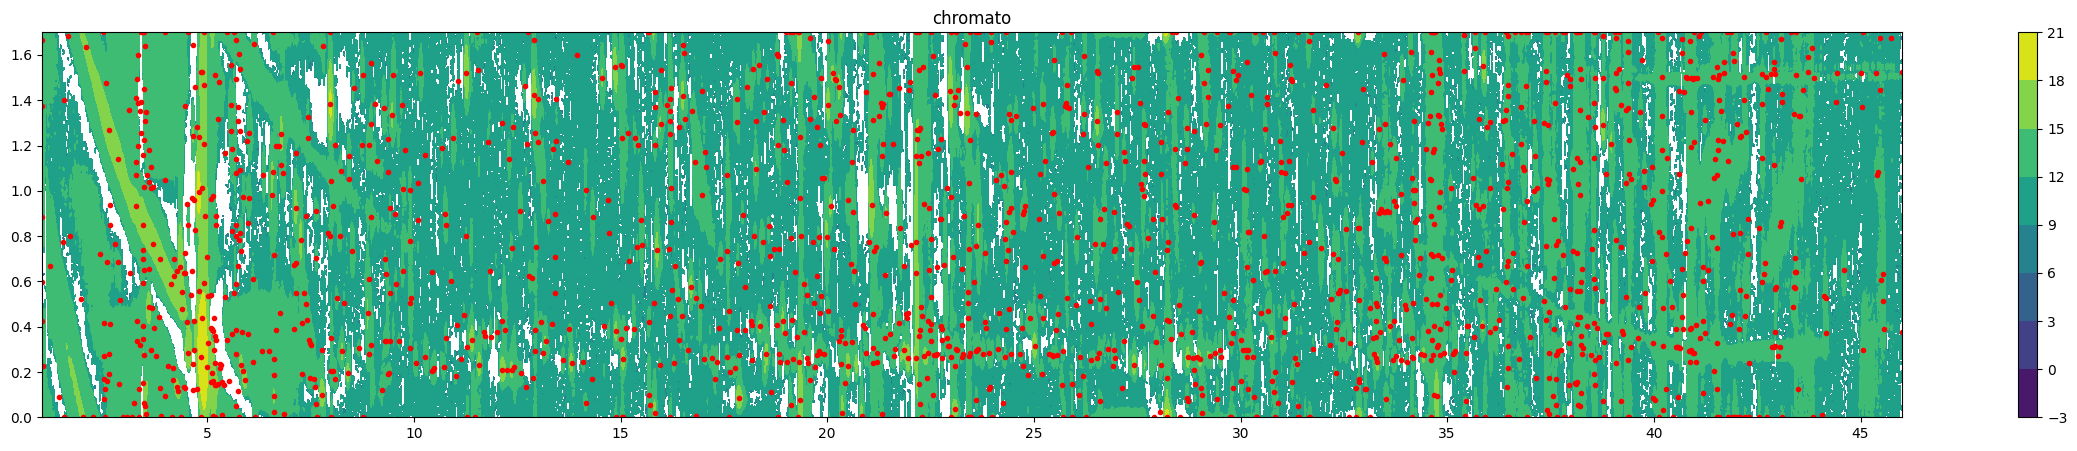

In [10]:
mod_time=1.7
coordinate = detection_mass_par_mass_Dog(chromato_cube,(chromato, time_rn),mod_time=mod_time,abs_threshold=1000,noise_factor=5, rel_threshold= 0.001)
plt.rcParams['figure.figsize'] = [30, 5]
coordinates_in_chromato=projection.matrix_to_chromato(coordinate, time_rn, mod_time, chromato.shape)
plot.visualizer2((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=mod_time,points=coordinates_in_chromato)

In [6]:
from dbscan_peak import detect_peak_dog_mp,cluster_per_mass,rt_penalty

results= detect_peak_dog_mp(chromato_cube,
                            abs_threshold=600,
                       rel_threshold=0.0001,
                       noise_factor=5,
                       min_sigma=1, max_sigma=20,
                       sigma_ratio=2,
                       overlap=0.5,multi_processing=True)
print("start cluster")    
results=cluster_per_mass(results,chromato_cube,time_rn,1.7,rt1_delta=5, rt2_delta=0.1,thr_debscan=0.05,max_peak_per_mass=600)
results = [res for res in results if res is not None]
coordinates_all_mass=[]
for elt in results:
    for x,y,z in elt:
        coordinates_all_mass.append([x,y,z])
    

start cluster


In [7]:
coordinates_all_mass = np.delete(coordinates_all_mass, 0, -1)
rt_values= projection.matrix_to_chromato(coordinates_all_mass, time_rn, 1.7, chromato_cube[0,:,:].shape)

In [8]:
intensity_values_list = []
for i, coordinate in enumerate(coordinates_all_mass):
    int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
    intensity_values_list.append(np.concatenate(([rt_values[i,0]*60,rt_values[i,1]], int_values)))
intensity_values_list = np.array(intensity_values_list)


In [9]:
rt_vals = intensity_values_list[:, :2]  # shape (n, 2)
spectra = intensity_values_list[:, 2:]  # shape (n, m)

In [10]:
from scipy.spatial.distance import cdist
import numpy as np

def rt_penalty_fast(rt_vals, rt1_delta=5, rt2_delta=0.1):
    # Normalize RTs by their respective deltas (acts like weighting)
    scaled_rt = rt_vals / np.array([rt1_delta, rt2_delta])
    
    # Compute Manhattan (L1) distance between all rows
    penalty_matrix = cdist(scaled_rt, scaled_rt, metric='cityblock')  # sum of |ΔRT1| + |ΔRT2|
    return penalty_matrix

In [11]:
rt_penalty_value= rt_penalty_fast(rt_vals,2,0.02)

In [12]:
from sklearn.metrics.pairwise import cosine_distances
batch_size=10000
import gc
# Assume `spectra` is already a (60000, m) numpy array
n_samples = spectra.shape[0]
    # Optional: use float32 to reduce memory (only if precision is acceptable)
spectra = spectra.astype(np.float32)

    # Preallocate output matrix
spec_dists = np.zeros((n_samples, n_samples), dtype=np.float32)

for start in range(0, n_samples, batch_size):
    print(start)
    end = min(start + batch_size, n_samples)

        # Compute distances from batch to all
    dist_batch = cosine_distances(spectra[start:end], spectra)
    spec_dists[start:end, :] = dist_batch

    del dist_batch
    gc.collect()




0
10000
20000
30000


In [15]:
spec_dists = spec_dists.astype(np.float32)
rt_penalty_value = rt_penalty_value.astype(np.float32)

In [16]:
distance_matrix = spec_dists + 0.01 *rt_penalty_value

In [13]:
# Only compute combined distance where rt_penalty_value < 1
mask = rt_penalty_value < 10

# Allocate result with NaNs or sparse format
final_dist = np.full_like(spec_dists, 1)
final_dist[mask] = spec_dists[mask] + 0.01 * rt_penalty_value[mask]

In [18]:
from dbscan_peak import cluster_peak
coordinates, clusters= cluster_peak(distance_matrix,chromato,coordinates_all_mass,thr_debscan=0.02,min_sample_db_scan=2)
len(coordinates)

4130

# Detecton masse par masse

In [252]:
chromato_cube_cut=chromato_cube_cut[:200,:,:]

In [ ]:
print("start peak detection")
results= dbscan_peak.detect_peak_dog_mp(chromato_cube_cut,0,
                       0.001,
                       3,
                       1, 20,
                       2,
                       0.5,multi_processing=True)
    

start peak detection


In [254]:
np.sum([len(x) for x in results])

203325

In [255]:
print("cluster_per_mass ")
results2=dbscan_peak.cluster_per_mass(results,chromato_cube_cut,time_rn_cut,1.7,rt1_delta=3, rt2_delta=0.1,thr_debscan=0.05,max_peak_per_mass=600)

cluster_per_mass 


In [256]:
np.sum([len(x) for x in results2])

59544

In [257]:
results2 = [res for res in results2 if res is not None]
coordinates_all_mass=[]
for elt in results2:
    for x,y,z in elt:
        coordinates_all_mass.append([x,y,z])

In [229]:
pdf.close()

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages('D:/detection_across_mass5.pdf')  # Open PDF explicitly
for i in range(chromato_cube_cut.shape[0]):
    index=[x[1:] for x in coordinates_all_mass if x[0]==i]
    coordinates_in_chromato=projection.matrix_to_chromato(np.array(index), time_rn_cut, 1.7, chromato_cut.shape)
    plt.rcParams['figure.figsize'] = [30, 5]
    fig=plot.visualizer2((chromato_cube_cut[i,:,:],time_rn_cut), title="mass " + str(i+35) + " " , log_chromato=True,  mod_time=1.7, rt1_window=0.15, rt2_window=0.2,points=coordinates_in_chromato)
    pdf.savefig(fig)  # Save current figure to PDF
    plt.close(fig)    # Close figure to free memory

pdf.close()  # Close the PDF file explicitly

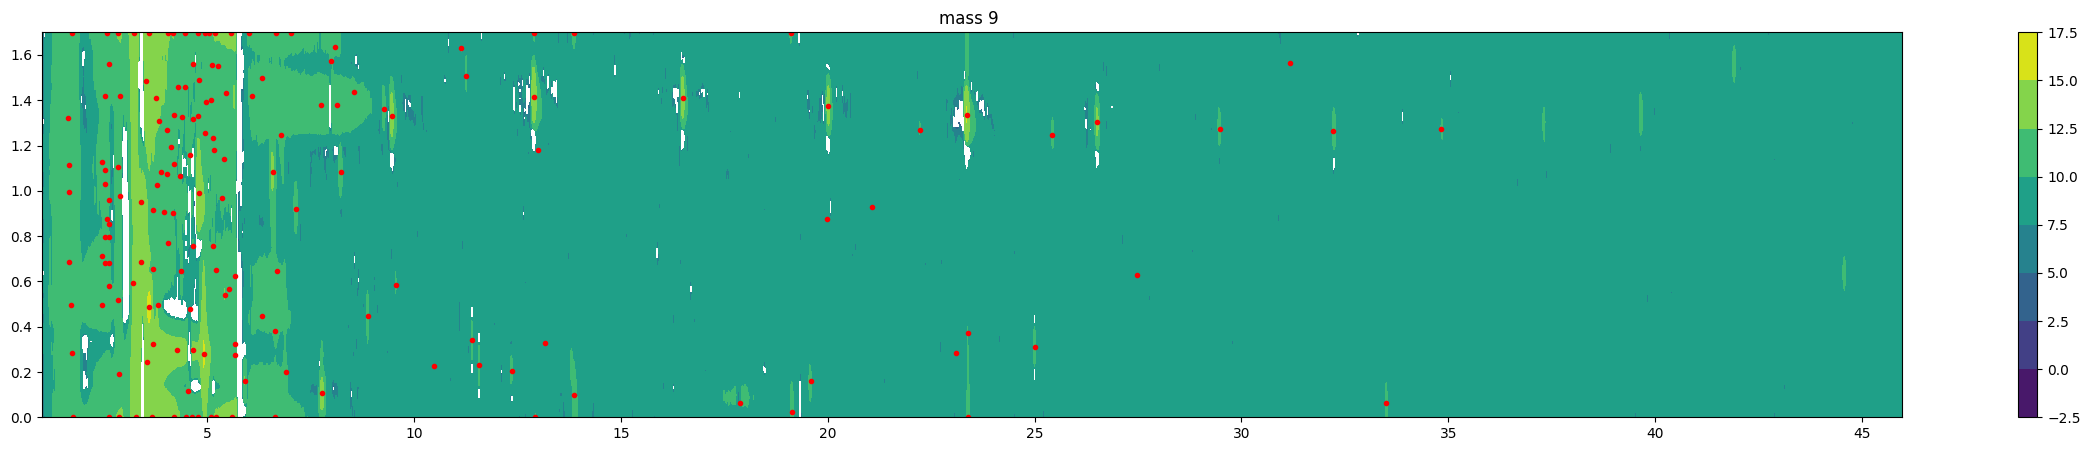

In [248]:
plt.rcParams['figure.figsize'] = [30, 5]

i=9
index=[x[1:] for x in coordinates_all_mass if x[0]==i]
coordinates_in_chromato=projection.matrix_to_chromato(np.array(index), time_rn, 1.7, chromato.shape)
plot.visualizer2((chromato_cube[i,:,:],time_rn), title="mass " + str(i) + " " , log_chromato=True,  mod_time=1.7, rt1_window=0.15, rt2_window=0.2,points=coordinates_in_chromato)

In [258]:
coordinates_all_mass = np.delete(coordinates_all_mass, 0, -1)

In [ ]:
print("compute distance metric "+ str(len(coordinates_all_mass)) + " peaks") 
distance_matrix= dbscan_peak.compute_distance_metric(coordinates_all_mass,chromato_cube_cut,1.7,time_rn_cut,rt1_delta=1, rt2_delta=0.02)
      
print("start clustering")
coordinates, clusters= dbscan_peak.cluster_peak(distance_matrix,chromato_cut,coordinates_all_mass,thr_debscan=0.02,min_sample_db_scan=3)

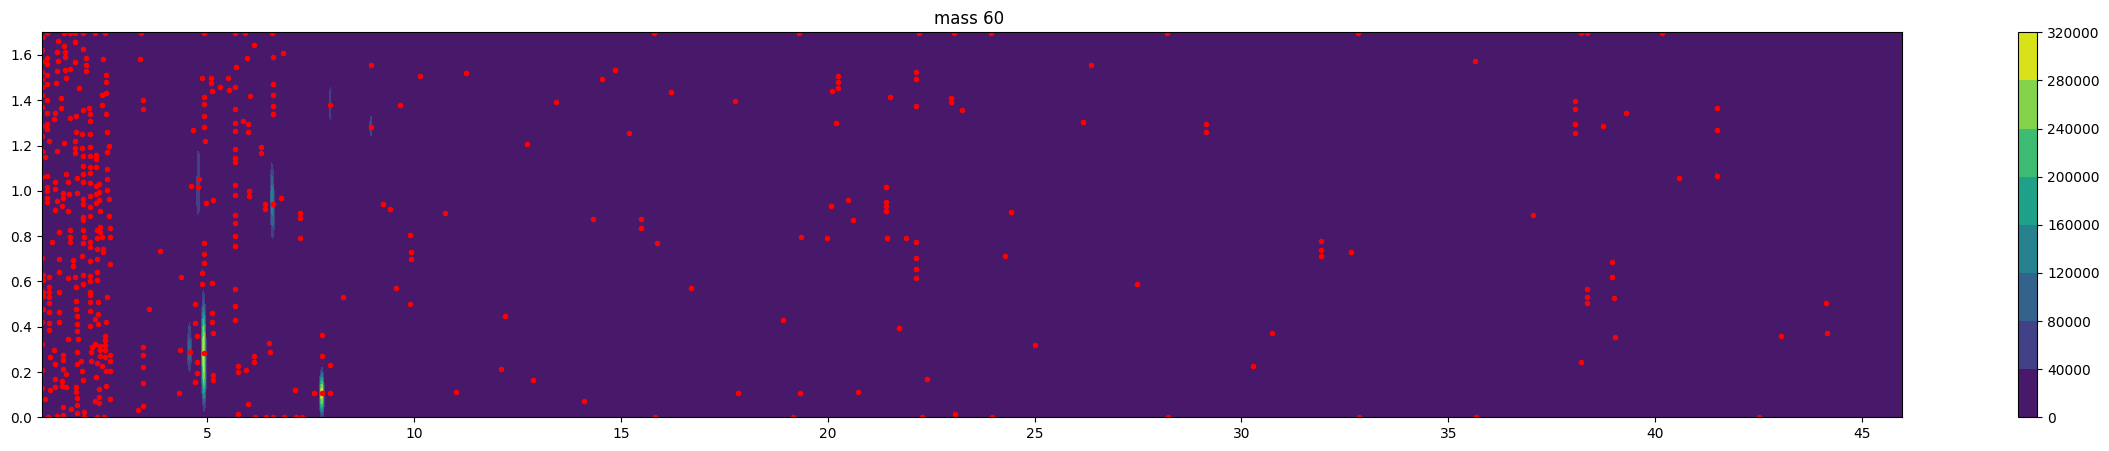

In [ ]:

from peak_detection import intensity_threshold_decision_rule, pers_hom, DoG
from dbscan_peak import detect_peak_dog
mass=78+mass_range[0]
#mass=49+mass_range[0]
mass=60
tmp= chromato_cube[mass-mass_range[0],:,:]

# sigma = estimate_sigma(tmp, channel_axis=None)
# MIN_SEUIL = min(2 * sigma * 100 / np.max(tmp),0.01)
# # detect peaks

# intensity_threshold = intensity_threshold_decision_rule(
#             abs_threshold=1000, rel_threshold=0.0000001, noise_factor=5, sigma=sigma, chromatogram=tmp)
# MIN_SEUIL= intensity_threshold / np.max(tmp)
# coordinates = skimage.feature.peak_local_max(
#             tmp,
#             min_distance=1,
#             threshold_abs=intensity_threshold)

# coordinates = pers_hom(chromato_obj=(
#                 tmp, time_rn),
#                 abs_threshold=1500,
#                 rel_threshold=0.00001,
#                 noise_factor=3,
#                 sigma=sigma,
#                 min_persistence=0.0002, mode="tic",
#                 chromato_cube=chromato_cube, cluster=0.5,
#                 eps=0.01,
#                 min_samples=1)
coordinates = detect_peak_dog(tmp,
                    0,
                    0.001,
                    3,
                    1, 20,
                    2,
                    0.5)

# intensity_values_list = []
# for i, coordinate in enumerate(coordinates):
#     int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
#     rt_values= projection.matrix_to_chromato(coordinates[[i]], time_rn, 1.7, chromato.shape)
#     intensity_values_list.append(np.concatenate(([rt_values[0,0]*60,rt_values[0,1]], int_values)))

# intensity_values_list = np.array(intensity_values_list)

# # Separate RT and spectrum
# rt_vals = intensity_values_list[:, :2]  # shape (n, 2)
# spectra = intensity_values_list[:, 2:]  # shape (n, m)

# # Compute cosine distances in vectorized form
# spec_dists = cosine_distances(spectra)

# # Compute RT penalty (broadcasted)
# rt1 = rt_vals[:, 0][:, None]
# rt2 = rt_vals[:, 0][None, :]
# rt1_penalty = np.abs(rt1 - rt2) / 5

# rt3 = rt_vals[:, 1][:, None]
# rt4 = rt_vals[:, 1][None, :]
# rt2_penalty = np.abs(rt3 - rt4) * 10

# total_penalty = 0.01 * (rt1_penalty + rt2_penalty)
# distance_matrix = spec_dists + total_penalty

# # Apply DBSCAN with precomputed distance matrix
# clustering = DBSCAN(eps=0.05, min_samples=1, metric='precomputed').fit(distance_matrix)

# clusters = []
# for i in range((np.max(clustering.labels_) + 1)):
#     clusters.append([])
# for i, (t1, t2) in enumerate(coordinates):
#     clusters[clustering.labels_[i]].append([t1, t2])
# coordinates = []
# for cluster in clusters:
#     if (len(cluster) > 1):
#         coord = cluster[np.argmax(np.array([tmp[coord[0], coord[1]] for coord in cluster]))]
#     else:
#         coord = cluster[0]
#     coordinates.append(coord)
# coordinates = np.array(coordinates)
# ncluster=len(clusters)

# if ncluster>600:
#     intensities = np.array([tmp[coord[0], coord[1]] for coord in coordinates])
#     top_indices = np.argsort(intensities)[-1000:][::-1]  # descending order
#     coordinates = coordinates[top_indices]
#     npeak= len(coordinates)


#visualizer2(((tmp), time_rn), title= str(npeak-ncluster) + " clustered peaks " + str(round(MIN_SEUIL,3)) + " " +str(ncluster), log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato_new)
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
plot.visualizer2((tmp, time_rn), title="mass " + str(mass) + " " , log_chromato=False,  mod_time=1.7, rt1_window=5, rt2_window=0.5,points=coordinates_in_chromato)


In [ ]:
pdf = PdfPages('D:/baseline.pdf')  # Open PDF explicitly

for mass in range(chromato_cube.shape[0])[:5]:
    tmp= chromato_cube[mass,:,:]
    fig=plot.visualizer2((tmp, time_rn), title="mass " + str(mass+35) + " " , log_chromato=True,  mod_time=1.7)
    pdf.savefig(fig)
    plt.close(fig)
    for i in range(tmp.shape[1]):
        tmp[:, i] = chromato[:, i] - pybaselines.whittaker.asls(chromato[:, i],
                                                       lam=10,
                                                       p=0.01)[0]
    tmp[tmp < .0] = 0    
    fig=plot.visualizer2((tmp, time_rn), title="mass " + str(mass+35) + " " , log_chromato=True,  mod_time=1.7)
    pdf.savefig(fig)
    plt.close(fig)
    sp=np.sum(chromato_cube[319-35,:,:],axis=1)
    sp=chromato_cube[mass,:,5]
    plt.plot(sp)
    plt.plot(pybaselines.whittaker.asls(sp,lam=10,p=0.01)[0])

pdf.close()  # Close the PDF file explicitly


chromato.shape

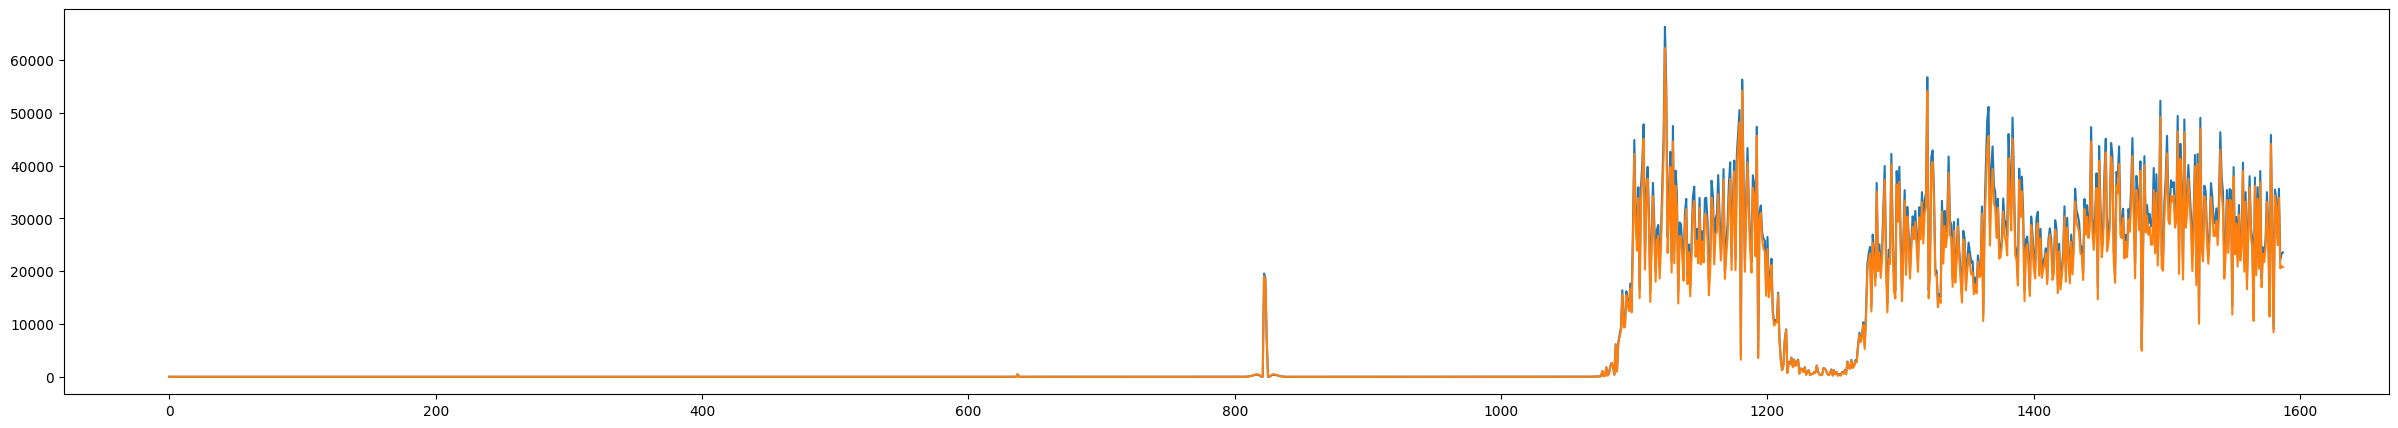

In [181]:
import pybaselines
mass=300
tmp= chromato_cube[mass-mass_range[0],:,:]
sp=np.sum(tmp,axis=1)
plt.plot(sp)
for i in range(tmp.shape[1]):
    tmp[:, i] = tmp[:, i] - pybaselines.whittaker.asls(tmp[:, i],
                                                       lam=1,
                                                       p=0.01)[0]
tmp[tmp < .0] = 0
sp=np.sum(tmp,axis=1)
plt.plot(sp)

#plt.plot(pybaselines.whittaker.asls(sp,lam=1,p=0.01)[0])

c:\Users\camil\OneDrive\Documents\02-Code source\Adeline\Python-2DGC-Alignment\src\plot.py:608: RuntimeWarning: divide by zero encountered in log
  chromato = np.log(chromato)


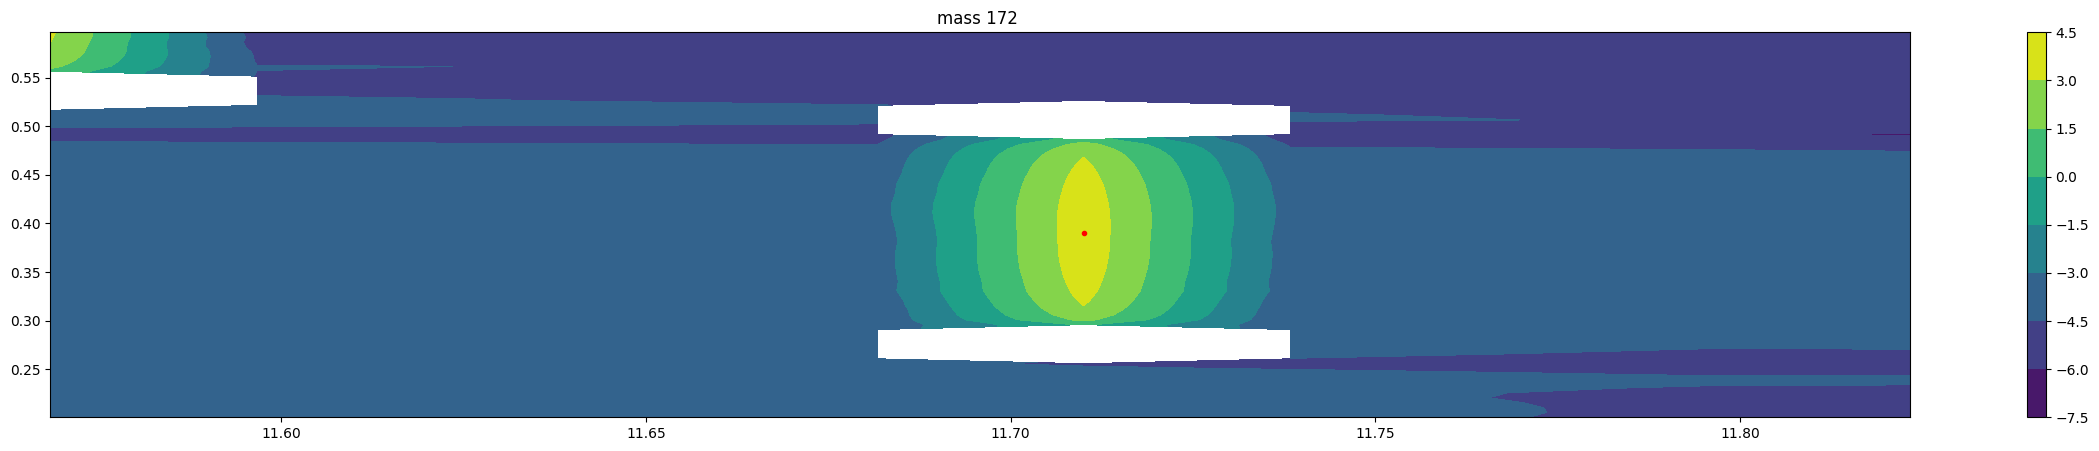

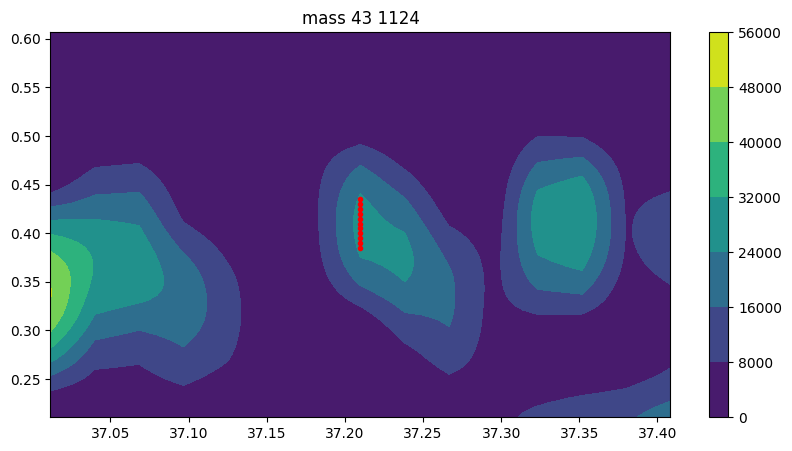

In [679]:
import integration
blob = integration.peak_pool_similarity_check(
            tmp, np.stack(coordinates), np.array([1278,   84]), chromato_cube,
            threshold=0.1, plot_labels=True,
            similarity_threshold=0.001)

# mask = np.zeros_like(blob)
# mask[504,: ] = blob[504,:]
# blob = mask

cds = np.argwhere(blob != 0)
area = integration.compute_area(tmp, blob)

plt.rcParams['figure.figsize'] = [10, 5]
coordinates_in_chromato_new=projection.matrix_to_chromato(cds, time_rn, 1.7, chromato.shape)
plot.visualizer2(((tmp), time_rn), title="mass " + str(mass) + " " +str(npeak), log_chromato=False,  mod_time=1.7,points=coordinates_in_chromato_new,rt1=37.21, rt2=0.41, rt1_window=0.2, rt2_window=0.2)

In [787]:
import numpy as np

def twoD_Gaussian_asym(coords, amplitude, xo, yo, sigma_x, sigma_y, theta, offset):
    """
    Asymmetric 2D Gaussian with rotation.
    coords: (x, y) meshgrid flattened
    amplitude: height of the peak
    xo, yo: center coordinates
    sigma_x, sigma_y: standard deviations along x and y
    theta: rotation angle in radians
    offset: baseline
    """
    x, y = coords
    xo = float(xo)
    yo = float(yo)
    a = (np.cos(theta)**2) / (2 * sigma_x**2) + (np.sin(theta)**2) / (2 * sigma_y**2)
    b = -(np.sin(2*theta)) / (4 * sigma_x**2) + (np.sin(2*theta)) / (4 * sigma_y**2)
    c = (np.sin(theta)**2) / (2 * sigma_x**2) + (np.cos(theta)**2) / (2 * sigma_y**2)
    g =  amplitude * np.exp(-(a*((x - xo)**2) + 2*b*(x - xo)*(y - yo) + c*((y - yo)**2)))
    return g.ravel()


from scipy.optimize import curve_fit
# Example: tmp is your 2D data array
coord=[938, 199]
tmp_plot=tmp[(coord[0]-7):(coord[0]+7), (coord[1]-20):(coord[1]+20)]
ny, nx = tmp_plot.shape
x = np.arange(nx)
y = np.arange(ny)
x, y = np.meshgrid(x, y)

# Initial parameter guess
initial_guess = (np.max(tmp), nx/2, ny/2, 3, 3, 0, np.min(tmp_plot))

# Fit the model
popt, pcov = curve_fit(twoD_Gaussian_asym, (x, y), tmp_plot.ravel(), p0=initial_guess)
fitted_data = twoD_Gaussian_asym((x, y), *popt).reshape(ny, nx)
area=np.sum(fitted_data)
area


983901.0694614467

In [383]:
import projection
import numpy as np
import plot
import mass_spec
import utils
from scipy import ndimage as ndi
from skimage.segmentation import watershed
import skimage
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
def peak_pool_similarity_check(chromato, coordinates, coordinate,
                               chromato_cube, threshold=0.25,
                               similarity_threshold=0.01, plot_labels=False):
    mask = np.zeros(chromato.shape, dtype=bool)
    mask[tuple(coordinates.T)] = True
    markers, _ = ndi.label(mask)
    peak_apex_int = chromato[coordinate[0]][coordinate[1]]
    img = np.where(chromato < threshold * peak_apex_int, 0, 1)
    # ajouter test si coord proche 0 ou 1.7, aller chercher dans la modulation avant/après 
    labels = watershed(-chromato, markers, mask=img)
    '''if (plot_labels):
        plot.visualizer((labels, time_rn), log_chromato=False)'''
    coordinate_label = labels[coordinate[0]][coordinate[1]]
    blob = np.where(labels != coordinate_label, 0, 1)

    if coordinate[1]<20 :
        coordinates_compl= [coordinate[0]-1,(chromato.shape[1]-1)]
        mask = np.zeros(chromato.shape, dtype=bool)
        mask[tuple(coordinates.T)] = True
        markers, _ = ndi.label(mask)
        peak_apex_int = chromato[coordinates_compl[0]][coordinates_compl[1]]
        img = np.where(chromato < threshold * peak_apex_int, 0, 1)
        # ajouter test si coord proche 0 ou 1.7, aller chercher dans la modulation avant/après 
        labels = watershed(-chromato, markers, mask=img)
        '''if (plot_labels):
            plot.visualizer((labels, time_rn), log_chromato=False)'''
        coordinate_label = labels[coordinates_compl[0]][coordinates_compl[1]]
        blob = blob + np.where(labels != coordinate_label, 0, 1)
    if coordinate[1]>(chromato.shape[1]-20):
        coordinates_compl= [coordinate[0]+1,0]
        mask = np.zeros(chromato.shape, dtype=bool)
        mask[tuple(coordinates.T)] = True
        markers, _ = ndi.label(mask)
        peak_apex_int = chromato[coordinates_compl[0]][coordinates_compl[1]]
        img = np.where(chromato < threshold * peak_apex_int, 0, 1)
        # ajouter test si coord proche 0 ou 1.7, aller chercher dans la modulation avant/après 
        labels = watershed(-chromato, markers, mask=img)
        '''if (plot_labels):
            plot.visualizer((labels, time_rn), log_chromato=False)'''
        coordinate_label = labels[coordinates_compl[0]][coordinates_compl[1]]
        blob = blob + np.where(labels != coordinate_label, 0, 1)
    cds = []
    for cd in np.argwhere(blob == 1):
        cds.append([cd[0], cd[1]])
    cds = np.array(cds)
    cds = integration.similarity_cluestering(chromato_cube, cds, ref_point=coordinate, similarity_threshold=similarity_threshold)
    res = np.zeros_like(chromato)
    for cd in cds:
        res[cd[0], cd[1]] = 1
    return res

In [ ]:

import integration
blob = peak_pool_similarity_check(
            tmp, np.stack(coordinates), np.array([484, 210]), chromato_cube,
            threshold=0.5, plot_labels=True,
            similarity_threshold=0.001)
cds = np.argwhere(blob != 0)
cds

fig, ax = plt.subplots()
#tmp = ax.pcolormesh(X, Y, chromato)
ax.contourf((tmp).T)
ax.plot(cds[:,0], cds[:,1],"r.")
ax.set_xlim([480,490])
ax.set_ylim([180,250])

In [ ]:
import projection
import numpy as np
import plot
import mass_spec
import utils
from scipy import ndimage as ndi
from skimage.segmentation import watershed
import skimage
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

coordinates=np.stack(coordinates)

coordinate=np.array([668, 124])
threshold=0.25


mask = np.zeros(chromato.shape, dtype=bool)
mask[tuple(coordinates.T)] = True
markers, _ = ndi.label(mask)
peak_apex_int = chromato[coordinate[0]][coordinate[1]]
img = np.where(chromato < threshold * peak_apex_int, 0, 1)
labels = watershed(-chromato, markers, mask=img)
coordinate_label = labels[coordinate[0]][coordinate[1]]
blob = np.where(labels != coordinate_label, 0, 1)
cds = []
for cd in np.argwhere(blob == 1):
       cds.append([cd[0], cd[1]])
cds = np.array(cds)
ref_point=coordinate



In [ ]:
intensity_values_list = []
ref_point_index = 0

for i, coordinate in enumerate(coordinates):
    if (coordinate[0] == ref_point[0] and coordinate[1] == ref_point[1]):
          ref_point_index = i
    int_values = mass_spec.read_spectrum_from_chromato_cube(
            coordinate, chromato_cube=chromato_cube)
    intensity_values_list.append(int_values)
intensity_values_list = np.array(intensity_values_list)
clustering = DBSCAN(eps=0.01, min_samples=1, metric='cosine').fit(intensity_values_list)

In [ ]:
from dbscan_peak import process_mass

results=[]
for mass in range(chromato_cube.shape[0]):
    results.append(process_mass(mass,chromato_cube,time_rn))

c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\camil\AppData\Loca

In [21]:
results=list

In [22]:
results = [x for x in results if x is not None]
list=[]
for elt in results:
    for x,y,z in elt:
        list.append([x,y,z])
len(list)

25720

In [ ]:
np.argmax([len(x) for x in results])

310

In [ ]:
plt.rcParams['figure.figsize'] = [20, 5]

pdf = matplotlib.backends.backend_pdf.PdfPages("C:/Users/camil/OneDrive/Documents/05-stages/2025- CDD GCgC/DBscan/plot_mass_detection_log_dog.pdf")
for mass in range(chromato_cube.shape[0]):
    chromato_m= chromato_cube[mass,:,:]
    tmp = np.empty_like(chromato)
    for i in range(tmp.shape[1]):
            tmp[:, i] = chromato_m[:, i] - pybaselines.whittaker.asls(chromato_m[:, i],
                                                        #lam=10**7,
                                                        lam=10**3, 
                                                        p=0.01,
                                                        #p=10**-3
                                                        )[0]
            tmp[tmp < .0] = 0
    tmp= savgol_filter(tmp,  50, 3, mode='nearest')
    tmp[tmp<0]=0

    sigma = estimate_sigma(tmp, channel_axis=None)
    MIN_SEUIL = min(2 * sigma * 100 / np.max(tmp),0.01)
    # detect peaks

    intensity_threshold = intensity_threshold_decision_rule(
                abs_threshold=1000, rel_threshold=0.0000001, noise_factor=5, sigma=sigma, chromatogram=tmp)
    MIN_SEUIL= intensity_threshold / np.max(tmp)
    # coordinates = skimage.feature.peak_local_max(
    #             tmp,
    #             min_distance=1,
    #             threshold_abs=intensity_threshold)

    # coordinates = pers_hom(chromato_obj=(
    #                 tmp, time_rn),
    #                 abs_threshold=1500,
    #                 rel_threshold=0.00001,
    #                 noise_factor=3,
    #                 sigma=sigma,
    #                 min_persistence=0.0002, mode="tic",
    #                 chromato_cube=chromato_cube, cluster=0.5,
    #                 eps=0.01,
    #                 min_samples=1)
    coordinates, radius = DoG(chromato_obj=(
                        tmp, time_rn),
                        abs_threshold=500,
                        rel_threshold=0.00001,
                        noise_factor=3,
                        sigma=sigma,
                        min_sigma=1, max_sigma=20,
                        sigma_ratio=2, mode="tic",
                        chromato_cube=chromato_cube, 
                        cluster=0.5,
                        overlap=0.5,
                        eps=0.1,
                        min_samples=1)
    npeak= len(coordinates)
    coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)

    intensity_values_list = []
    for i, coordinate in enumerate(coordinates):
        int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
        rt_values= projection.matrix_to_chromato(coordinates[[i]], time_rn, 1.7, chromato.shape)
        intensity_values_list.append(np.concatenate(([rt_values[0,0]*60,rt_values[0,1]], int_values)))

    intensity_values_list = np.array(intensity_values_list)

    # Separate RT and spectrum
    rt_vals = intensity_values_list[:, :2]  # shape (n, 2)
    spectra = intensity_values_list[:, 2:]  # shape (n, m)

    # Compute cosine distances in vectorized form
    spec_dists = cosine_distances(spectra)

    # Compute RT penalty (broadcasted)
    rt1 = rt_vals[:, 0][:, None]
    rt2 = rt_vals[:, 0][None, :]
    rt1_penalty = np.abs(rt1 - rt2) / 5

    rt3 = rt_vals[:, 1][:, None]
    rt4 = rt_vals[:, 1][None, :]
    rt2_penalty = np.abs(rt3 - rt4) * 10

    total_penalty = 0.01 * (rt1_penalty + rt2_penalty)
    distance_matrix = spec_dists + total_penalty

    # Apply DBSCAN with precomputed distance matrix
    clustering = DBSCAN(eps=0.05, min_samples=1, metric='precomputed').fit(distance_matrix)

    clusters = []
    for i in range((np.max(clustering.labels_) + 1)):
        clusters.append([])
    for i, (t1, t2) in enumerate(coordinates):
        clusters[clustering.labels_[i]].append([t1, t2])
    coordinates = []
    for cluster in clusters:
        if (len(cluster) > 1):
            coord = cluster[np.argmax(np.array([tmp[coord[0], coord[1]] for coord in cluster]))]
        else:
            coord = cluster[0]
        coordinates.append(coord)
    coordinates = np.array(coordinates)
    ncluster=len(clusters)

    if ncluster>600:
        intensities = np.array([tmp[coord[0], coord[1]] for coord in coordinates])
        top_indices = np.argsort(intensities)[-1000:][::-1]  # descending order
        coordinates = coordinates[top_indices]
        npeak= len(coordinates)

    coordinates_in_chromato_new=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
    fig1=visualizer2(((tmp), time_rn), title="mass " + str(mass + mass_range[0]) + " " +str(npeak), log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)
    fig2=visualizer2(((tmp), time_rn), title= str(npeak-ncluster) + " clustered peaks " + str(round(MIN_SEUIL,3)) + " " +str(ncluster), log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato_new)
    pdf.savefig(fig1)
    plt.close(fig1) 
    pdf.savefig(fig2)
    plt.close(fig2)
    print(mass)
pdf.close()

# Clusturing across mass

In [ ]:
coordinates_all_mass=list
coordinates_all_mass


In [ ]:
coordinates_all_mass = np.delete(coordinates_all_mass, 0, -1)
intensity_values_list = []
for i, coordinate in enumerate(coordinates_all_mass):
    int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
    rt_values= projection.matrix_to_chromato(coordinates_all_mass[[i]], time_rn, 1.7, chromato.shape)
    intensity_values_list.append(np.concatenate(([rt_values[0,0]*60,rt_values[0,1]], int_values)))

intensity_values_list = np.array(intensity_values_list)
#from dbscan_peak import rt_penalty, cluster_peak
rt_vals = intensity_values_list[:, :2]  # shape (n, 2)
spectra = intensity_values_list[:, 2:]  # shape (n, m)


In [130]:
# Compute cosine distances in vectorized form
spec_dists = cosine_distances(spectra)

In [15]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
import gc
# Assume `spectra` is already a (60000, m) numpy array
n_samples = spectra.shape[0]
batch_size = 20000  # can adjust based on your RAM

# Optional: use float32 to reduce memory (only if precision is acceptable)
spectra = spectra.astype(np.float32)

# Preallocate output matrix
spec_dists = np.zeros((n_samples, n_samples), dtype=np.float32)

for start in range(0, n_samples, batch_size):
    end = min(start + batch_size, n_samples)
    print(f"Processing rows {start} to {end}...")

    # Compute distances from batch to all
    dist_batch = cosine_distances(spectra[start:end], spectra)
    spec_dists[start:end, :] = dist_batch

    del dist_batch
    gc.collect()

print("Full cosine distance matrix computed with shape:", spec_dists.shape)

Processing rows 0 to 20000...
Processing rows 20000 to 34803...
Full cosine distance matrix computed with shape: (34803, 34803)


In [131]:
rt_penalty_value= rt_penalty(rt_vals,rt1_delta=2, rt2_delta=0.02)
distance_matrix = spec_dists + 0.01 *rt_penalty_value
clustering = DBSCAN(eps=0.02, min_samples=2, metric='precomputed').fit(distance_matrix)

In [132]:
labels = clustering.labels_
unique_labels = set(labels)
unique_labels.discard(-1)  # Ignore noise
intra_distances =[]
for label in unique_labels:
    cluster_points = coordinates_all_mass[labels == label]
    if len(cluster_points) > 1:
            centroid = np.mean(cluster_points, axis=0)
            dists = np.linalg.norm(cluster_points - centroid, axis=1)
            intra_distances.append(np.mean(dists))

overall_mean = np.mean(intra_distances) if intra_distances else np.nan
overall_mean

1.7397744566642552

In [133]:
labels = clustering.labels_
unique_labels = set(labels)
unique_labels.discard(-1)  # Ignore noise
ncluster=len(unique_labels)

clusters = []
for i in range(ncluster):
    clusters.append([])
for i, (t1, t2) in enumerate(coordinates_all_mass):
    if(clustering.labels_[i]!= -1):
        clusters[clustering.labels_[i]].append([t1, t2])
coordinates = []
for cluster in clusters:
    if (len(cluster) > 1):
        coord = cluster[np.argmax(np.array([chromato[coord[0], coord[1]] for coord in cluster]))]
    else:
        coord = cluster[0]
    coordinates.append(coord)
coordinates = np.array(coordinates)
len(coordinates)

2132

In [10]:
coordinates= detection_mass_par_mass(chromato_cube,chromato, time_rn, mass_range)

c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [116]:
len(coordinates)

5134

In [134]:
intensity_values_list = []
for i, coordinate in enumerate(coordinates):
    int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
    rt_values= projection.matrix_to_chromato(coordinates[[i]], time_rn, 1.7, chromato.shape)
    intensity_values_list.append(np.concatenate(([rt_values[0,0]*60,rt_values[0,1]], int_values)))

intensity_values_list = np.array(intensity_values_list)

# Separate RT and spectrum
rt_vals = intensity_values_list[:, :2]  # shape (n, 2)
spectra = intensity_values_list[:, 2:]  # shape (n, m)

# Compute cosine distances in vectorized form
spec_dists = cosine_distances(spectra)

# Compute RT penalty (broadcasted)
rt1 = rt_vals[:, 0][:, None]
rt2 = rt_vals[:, 0][None, :]
rt1_penalty = np.abs(rt1 - rt2) / 2*1.7

rt3 = rt_vals[:, 1][:, None]
rt4 = rt_vals[:, 1][None, :]
rt2_penalty = np.abs(rt3 - rt4) / 0.1

total_penalty = 0.01 * (rt1_penalty + rt2_penalty)
distance_matrix = spec_dists + total_penalty

# Apply DBSCAN with precomputed distance matrix
clustering = DBSCAN(eps=0.03, min_samples=1, metric='precomputed').fit(distance_matrix)

In [135]:
labels = clustering.labels_
unique_labels = set(labels)
unique_labels.discard(-1)  # Ignore noise
ncluster=len(unique_labels)

clusters = []
for i in range(ncluster):
    clusters.append([])
for i, (t1, t2) in enumerate(coordinates):
    if(clustering.labels_[i]!= -1):
        clusters[clustering.labels_[i]].append([t1, t2])
coordinates_final = []
for cluster in clusters:
    if (len(cluster) > 1):
        coord = cluster[np.argmax(np.array([chromato[coord[0], coord[1]] for coord in cluster]))]
    else:
        coord = cluster[0]
    coordinates_final.append(coord)
coordinates_final = np.array(coordinates_final)
len(coordinates_final)

1806

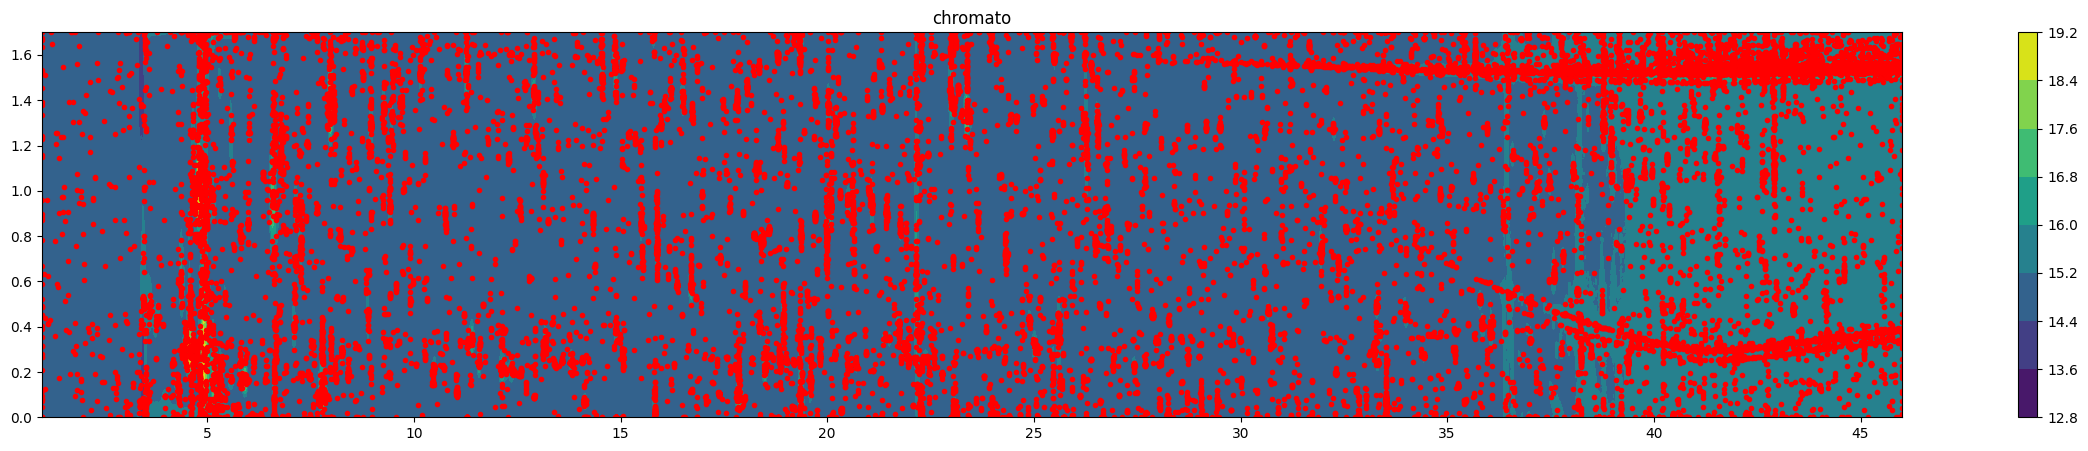

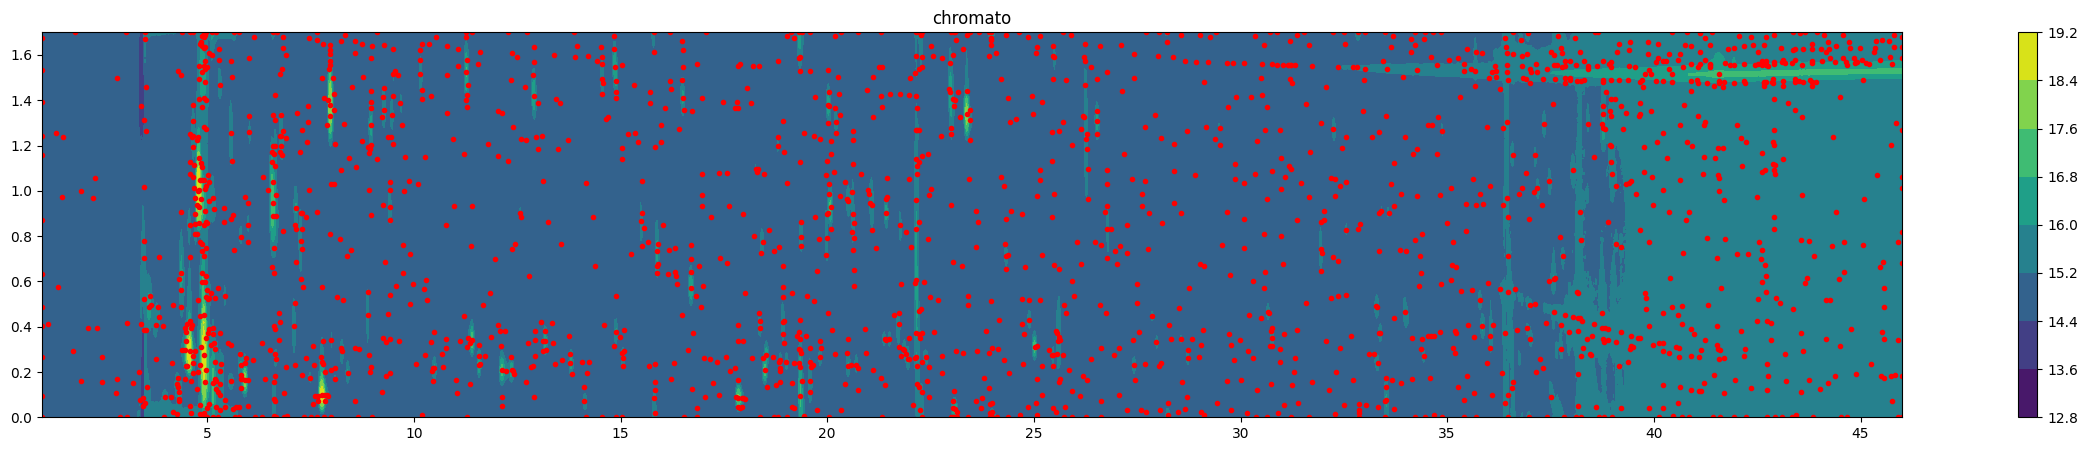

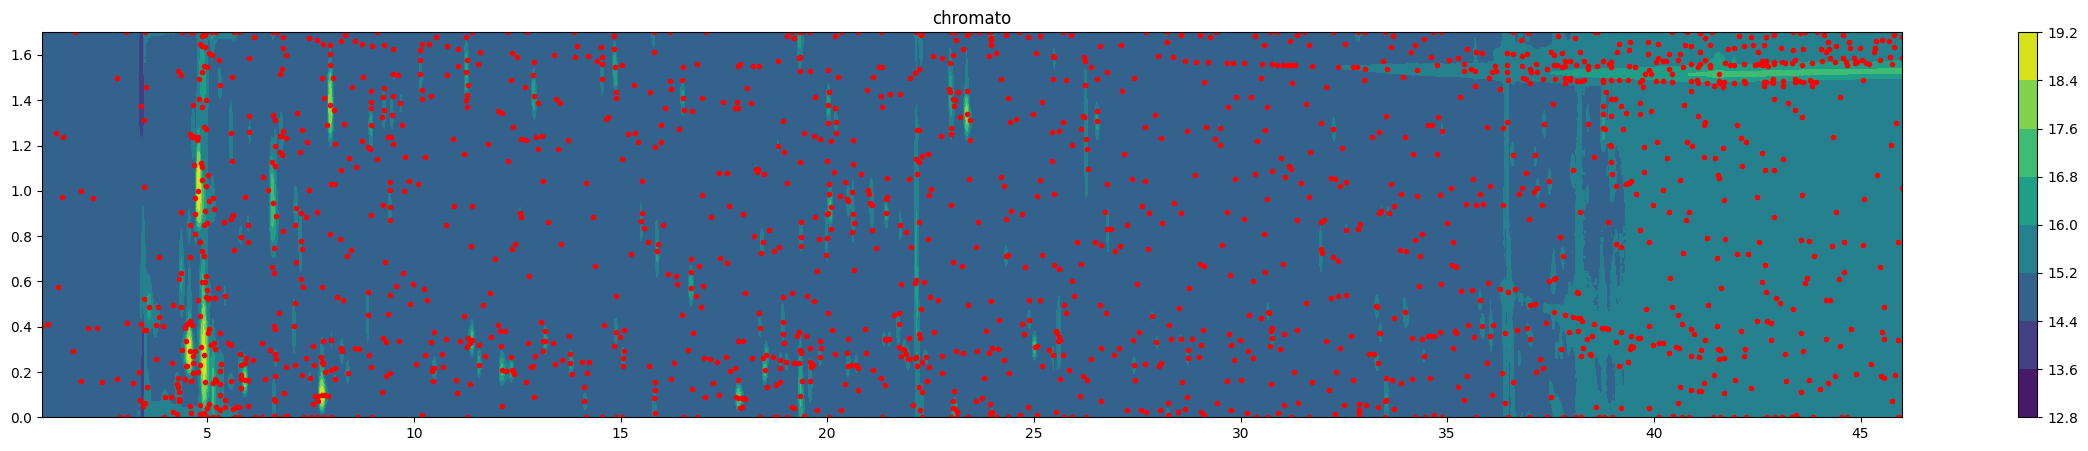

In [136]:
plt.rcParams['figure.figsize'] = [30, 5]
coordinates_in_chromato=projection.matrix_to_chromato(coordinates_all_mass, time_rn, 1.7, chromato.shape)
visualizer2((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
visualizer2((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)
coordinates_in_chromato=projection.matrix_to_chromato(coordinates_final, time_rn, 1.7, chromato.shape)
visualizer2((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)

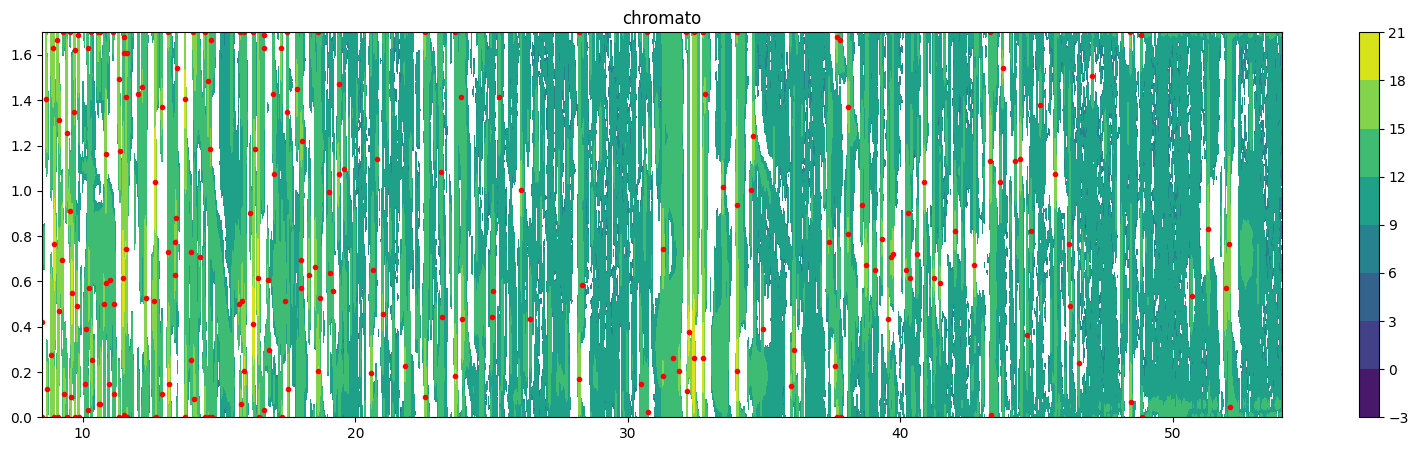

In [56]:
seuil=1
MIN_SEUIL = seuil * sigma * 100 / np.max(chromato)
# detect peaks
#coordinates = peak_detection((chromato, time_rn, None), None, chromato_cube, MIN_SEUIL, None , mode='tic' )
coordinates_TIC = peak_detection((chromato, time_rn, mass_range), spectra=mass_range, mod_time=1.7,method = "persistent_homology",chromato_cube=chromato_cube,    
                             seuil=0.005,ABS_THRESHOLDS=None, mode='tic', cluster=True,  
                             min_distance=1, sigma_ratio=1.6, num_sigma=10, unique=False)
len(coordinates_TIC)
coordinates_in_chromato_TIC=projection.matrix_to_chromato(coordinates_TIC, time_rn, 1.7, chromato.shape)
plot.visualizer((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato_TIC)

In [ ]:
coordinates_all_mass = np.delete(coordinates_all_mass, 0, -1) # supp l'info de la mass



clustering = DBSCAN(eps=0.5, min_samples=5).fit(coordinates_all_mass) # lance DBscan
clusters = []
for i in range((np.max(clustering.labels_) + 1)):
    clusters.append([])

for i, (t1, t2) in enumerate(coordinates_all_mass):
    clusters[clustering.labels_[i]].append([t1, t2])

# clusters = np.array(clusters)
# Coordinates of the point with the biggest intensity in the cluster for every clusters
coordinates = []
for cluster in clusters:
    if (len(cluster) > 1):
        #coord = cluster[np.argmax(np.array([chromato[coord[0], coord[1]] for coord in cluster]))]
        arr=np.array(cluster)
        median_x = np.median(arr[:, 0])  # Median of first coordinate
        median_y = np.median(arr[:, 1])  # Median of second coordinate
        coord=[round(median_x),round(median_y)]
    else:
        coord = cluster[0]
    coordinates.append(coord)
coordinates = np.array(coordinates)

# anotate table

In [2]:
import pandas as pd
import logging
import pyms
import pyms_nist_search

def serialize_hit_tuple(hit_tuple):
        search_result, ref_data = hit_tuple
        return {
            "name": getattr(search_result, "name", None),
            "match_factor": getattr(search_result, "match_factor", None),
            "cas_number": getattr(search_result, "cas", None),
            "formula": getattr(ref_data, "formula", None),
        }

def filter_best_hits(list_hits, match_factor_min):
    match_factors = [hit["match_factor"] for hit in list_hits]
    max_match_factor = max(match_factors, default=0)

    filtered_hits = [
        hit for hit in list_hits
        if hit["match_factor"] >= max_match_factor - 100
        and hit["match_factor"] >= match_factor_min
    ]
    return filtered_hits

def matching_nist(df,match_factor_min):  
    search = pyms_nist_search.Engine(
        "C:/Users/camil/Documents/NIST/mainlib/",
        pyms_nist_search.NISTMS_MAIN_LIB,
        "C:/Users/camil/Documents/NIST/mainlib/",
        )

    logger=logging.getLogger('pyms_nist_search')
    logger.setLevel('ERROR')
    logger=logging.getLogger('pyms')
    logger.setLevel('ERROR')

    df['compound_name'] = ""
    df['casno'] = ""
    df['compound_formula'] = ""
    df['match_factor'] = ""

    for row in range(df.shape[0]):
        s = df.at[row, 'Spectra']
        pairs = s.strip().split()

        masses = []
        intensities = []

        for pair in pairs:
                m, i = pair.split(":")
                masses.append(int(float(m)))  #  or float(m) if decimals matter
                intensities.append(float(i))
        
        list_hits = []
        mass_spectrum = pyms.Spectrum.MassSpectrum(masses, intensities)

        hits = search.full_search_with_ref_data(mass_spectrum, n_hits=20)
        for i, hit_tuple in enumerate(hits):
            results = serialize_hit_tuple(hit_tuple)
            list_hits.append(results)
        top_hits = filter_best_hits(list_hits, match_factor_min)

        def join_field(field):
            return '/'.join(str(m.get(field, '')) for m in top_hits)

        if top_hits:
            identification_data_dict = {
            'compound_name': join_field('name'),
            'casno': join_field('cas_number'),
            'compound_formula': join_field('formula'),
            'match_factor': join_field('match_factor'),
        }
            for key in identification_data_dict:
                df.at[row, key] = identification_data_dict[key]

    return df



In [ ]:

import warnings
warnings.filterwarnings("ignore")
match_factor_min = 600
df = pd.read_csv("C:/Users/camil/data/td-ptr/gcxgc/GCxGC_VOLATIL-CF_06/output_deconvo/Align_table_blk_sample_8_6_info.csv", sep=";")
df = matching_nist(df,match_factor_min)
df.to_csv("C:/Users/camil/data/td-ptr/gcxgc/GCxGC_VOLATIL-CF_06/output_deconvo/Align_table_blk_sample_8_6_info_annotate.csv", sep=";", index=False, encoding="utf-8-sig") #compatibilite avec excel0

In [5]:
df.to_csv("C:/Users/camil/data/VOC-Compare/gcgc/resultats_deconvo/Align_table_tedlar_info_annotate.csv", sep=";", index=False, encoding="utf-8-sig") #compatibilite avec excel

In [18]:
df

,Name,R.T...s.,Area,Quant.Masses,Spectra,RT1,RT2,compound_name,casno,compound_formula,match_factor
0,Analyte1021_1,"""63.400003504 , 1.08""","618366,676820492",True,45.0:5886166.850680556 46.0:2435927.07116656 4...,"63,400003504","1,08",Ethanol,64-17-5,C2H6O,942
1,Analyte322_1,"""70.200003504 , 1.685""","2108750401,69099",True,45.0:15746941.153875027 46.0:8017474.81114812 ...,"70,200003504","1,685",Ethanol,64-17-5,C2H6O,958
2,Analyte41_1,"""73.60000350399999 , 0.0""","4456572454,64972",True,45.0:17464758.200306904 46.0:8815108.618039127...,"73,600003504",0,Ethanol,64-17-5,C2H6O,960
3,Analyte1289_1,"""77.00000350399999 , 1.32""","1159832,68345092",True,207.0:15567.294322392794 208.0:3253.7510938291...,"77,000003504","1,32","Cyclotrisiloxane, hexamethyl-/Tris(tert-butyld...",541-5-9/---/55429-29-3/---,C6H18O3Si3/C18H45AsO3Si3/C9H27AsO3Si3/C13H20N2SSi,777/736/717/691
4,Analyte38_1,"""83.800003504 , 1.3""","1048511,73661597",True,45.0:6527594.012989905 46.0:2736616.2876030337...,"83,800003504","1,3",Ethanol,64-17-5,C2H6O,943
...,...,...,...,...,...,...,...,...,...,...,...
742,Analyte333_1,"""2718.8000035039995 , 0.7000000000000001""","2501996,65724585",True,57.0:56438.9949229279 43.0:40677.0187545393 71...,"2718,800003504","0,7",Hexadecane/Eicosane/Heptadecane/Pentadecane/Do...,544-76-3/112-95-8/629-78-7/629-62-9/31295-56-4...,C16H34/C20H42/C17H36/C15H32/C15H32/C21H44/C19H...,847/839/836/835/834/831/830/823/823/819/817/81...
743,Analyte1356_1,"""2720.500003504 , 0.185""","41355,6432220882",True,220.0:8180.553963377228 77.0:4345.015382001947...,"2720,500003504","0,185",,,,
744,Analyte1358_1,"""2720.500003504 , 0.41500000000000004""","103520,835529405",True,220.0:6631.23399744275 44.0:2824.009871004426 ...,"2720,500003504","0,415","1,2,3,4-Tetrahydrobenzo[a]fluorene/1H-Pyrazole...",6567-9-5/24567-8-6/36159-74-7/7072-0-6/55484-5...,C17H16/C15H12N2/C16H12O/C16H12O/C15H12N2/C17H1...,686/673/670/666/664/661/651
745,Analyte616_1,"""2749.4000035040003 , 0.715""","1688078,5813308",True,244.0:6668.327500186932 44.0:3398.478591045728...,"2749,400003504","0,715",2-Phenyldibenzofuran/4-Phenyldibenzofuran/1-Ph...,78210-31-8/---/---,C18H12O/C18H12O/C18H12O,754/725/677


In [21]:
df.to_csv("D:/GCxGC/gamme/output_als_2/Align_table_info_annotate.csv", sep=";", index=False, encoding="utf-8-sig") #compatibilite avec excel

In [ ]:
filename= "D:/"
chromato, time_rn, chromato_cube, sigma, mass_range=read_chromato_and_chromato_cube(filename, mod_time=1.7, pre_process=True)

In [55]:
plot.visualizer2((chromato_cube[m-mass_range[0]], time_rn), title="chromato", log_chromato=True,  mod_time=1.7, rt1=5.5,rt2=1.66, rt2_window=0.7, rt1_window=1)

NameError: name 'm' is not defined